In [ ]:
from datasets import load_dataset

# Cargar la versión Parquet del dataset (sin necesidad de trust_remote_code)
dataset = load_dataset("OpenRL/daily_dialog")

# Imprimir tamaños de las particiones
print("--- TAMAÑO DEL DATASET ---")
print(f"Entrenamiento: {dataset['train'].num_rows} diálogos")
print(f"Validación: {dataset['validation'].num_rows} diálogos")
print(f"Prueba: {dataset['test'].num_rows} diálogos\n")

# Mostrar el primer ejemplo
ejemplo = dataset['train'][0]

print("--- EJEMPLO DE DATOS ---")
print("Diálogo:", ejemplo['dialog'])
print("Emociones por frase:", ejemplo['emotion'])
print("Actos de diálogo por frase:", ejemplo['act'])


--- TAMAÑO DEL DATASET ---
Entrenamiento: 11118 diálogos
Validación: 1000 diálogos
Prueba: 1000 diálogos

--- EJEMPLO DE DATOS ---
Diálogo: ['Say , Jim , how about going for a few beers after dinner ? ', ' You know that is tempting but is really not good for our fitness . ', ' What do you mean ? It will help us to relax . ', " Do you really think so ? I don't . It will just make us fat and act silly . Remember last time ? ", " I guess you are right.But what shall we do ? I don't feel like sitting at home . ", ' I suggest a walk over to the gym where we can play singsong and meet some of our friends . ', " That's a good idea . I hear Mary and Sally often go there to play pingpong.Perhaps we can make a foursome with them . ", ' Sounds great to me ! If they are willing , we could ask them to go dancing with us.That is excellent exercise and fun , too . ', " Good.Let ' s go now . ", ' All right . ']
Emociones por frase: [0, 0, 0, 0, 0, 0, 4, 4, 4, 4]
Actos de diálogo por frase: [3, 4, 2, 2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

# Cargar la versión Parquet
dataset = load_dataset("OpenRL/daily_dialog")

# Imprimir tamaños de las particiones
print("--- TAMAÑO DEL DATASET ---")
print(f"Entrenamiento: {dataset['train'].num_rows} diálogos")
print(f"Validación: {dataset['validation'].num_rows} diálogos")
print(f"Prueba: {dataset['test'].num_rows} diálogos\n")

# Convertir a Pandas DataFrame para el análisis (usaremos la de entrenamiento)
df_train = dataset['train'].to_pandas()

print("--- VISTAZO A LOS DATOS (Primeras 2 filas) ---")
display(df_train.head(2))

--- TAMAÑO DEL DATASET ---
Entrenamiento: 11118 diálogos
Validación: 1000 diálogos
Prueba: 1000 diálogos

--- VISTAZO A LOS DATOS (Primeras 2 filas) ---


,dialog,act,emotion
0,"[Say , Jim , how about going for a few beers a...","[3, 4, 2, 2, 2, 3, 4, 1, 3, 4]","[0, 0, 0, 0, 0, 0, 4, 4, 4, 4]"
1,"[Can you do push-ups ? , Of course I can . It...","[2, 1, 2, 2, 1, 1]","[0, 0, 6, 0, 0, 0]"


--- ESTADÍSTICAS: LONGITUD DEL DIÁLOGO ---
count    11118.000000
mean         7.840439
std          4.007963
min          2.000000
25%          4.000000
50%          7.000000
75%         10.000000
max         35.000000
Name: num_turns, dtype: float64


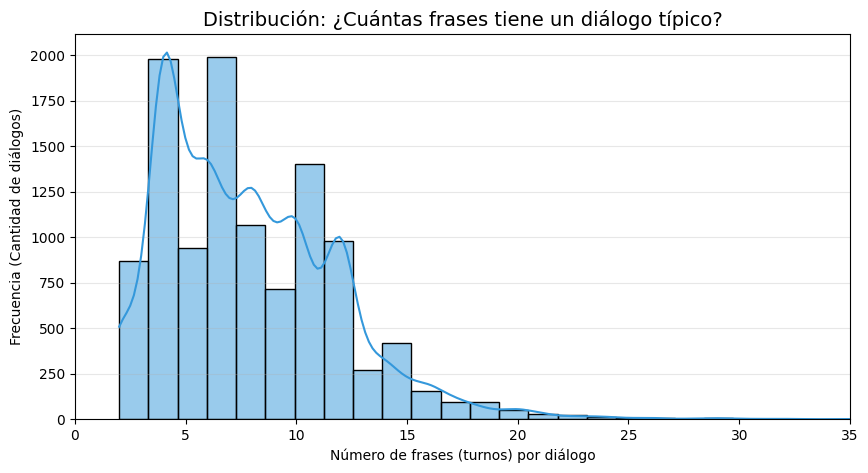

In [ ]:
# Calcular la cantidad de turnos (frases) por cada diálogo
df_train['num_turns'] = df_train['dialog'].apply(len)

print("--- ESTADÍSTICAS: LONGITUD DEL DIÁLOGO ---")
print(df_train['num_turns'].describe())

# Graficar la distribución
plt.figure(figsize=(10, 5))
sns.histplot(df_train['num_turns'], bins=25, kde=True, color='#3498db')
plt.title('Distribución: ¿Cuántas frases tiene un diálogo típico?', fontsize=14)
plt.xlabel('Número de frases (turnos) por diálogo')
plt.ylabel('Frecuencia (Cantidad de diálogos)')
plt.xlim(0, 35) # Limitamos a 35 porque la mayoría cae aquí
plt.grid(axis='y', alpha=0.3)
plt.show()

/tmp/ipykernel_8641/2930895116.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(
/tmp/ipykernel_8641/2930895116.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


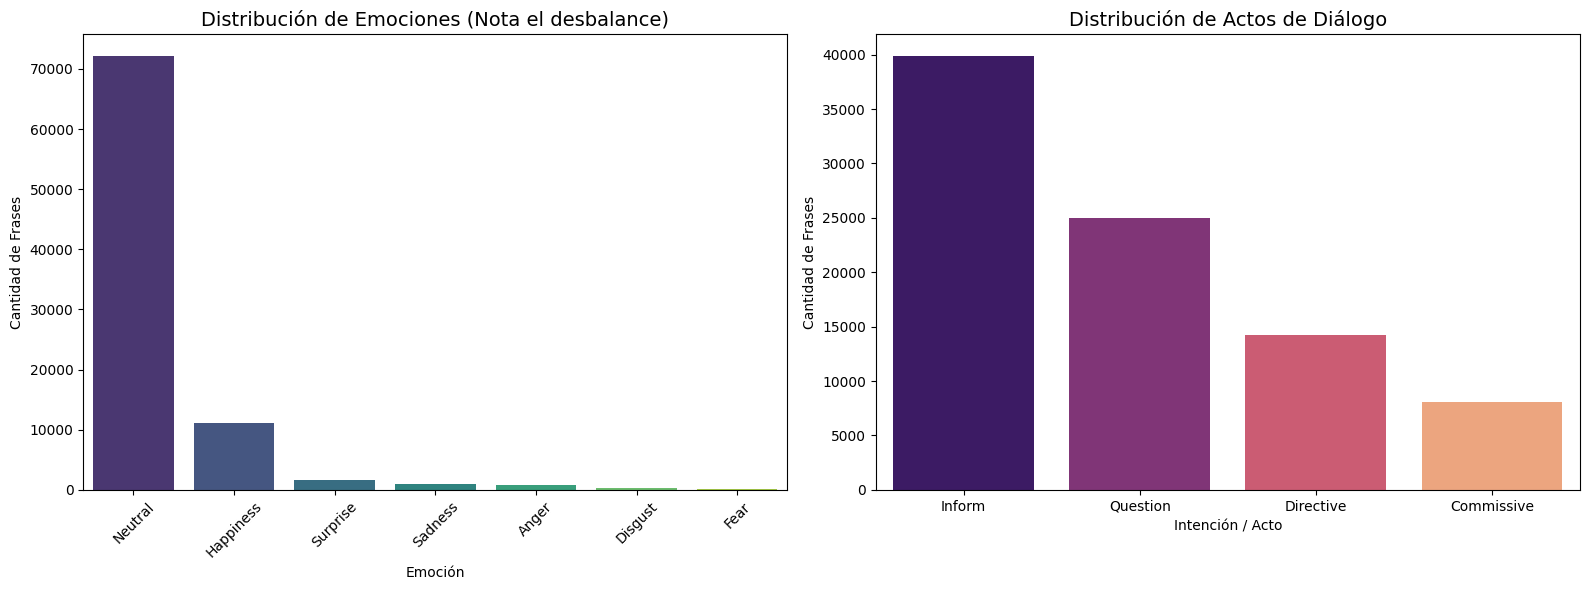

In [ ]:
# "Explotar" las listas para que cada frase tenga su propia fila
df_frases = df_train.explode(['dialog', 'emotion', 'act'])

# Diccionarios para traducir los números a texto
emotion_map = {0: 'Neutral', 1: 'Anger', 2: 'Disgust', 3: 'Fear',
               4: 'Happiness', 5: 'Sadness', 6: 'Surprise'}
act_map = {1: 'Inform', 2: 'Question', 3: 'Directive', 4: 'Commissive'}

# Crear nuevas columnas con los nombres legibles
df_frases['emotion_name'] = df_frases['emotion'].map(emotion_map)
df_frases['act_name'] = df_frases['act'].map(act_map)

# Crear la figura con dos gráficos (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Emociones
sns.countplot(
    data=df_frases,
    x='emotion_name',
    order=df_frases['emotion_name'].value_counts().index,
    ax=axes[0],
    palette='viridis'
)
axes[0].set_title('Distribución de Emociones (Nota el desbalance)', fontsize=14)
axes[0].set_ylabel('Cantidad de Frases')
axes[0].set_xlabel('Emoción')
axes[0].tick_params(axis='x', rotation=45)

# Gráfico 2: Actos de Diálogo
sns.countplot(
    data=df_frases,
    x='act_name',
    order=df_frases['act_name'].value_counts().index,
    ax=axes[1],
    palette='magma'
)
axes[1].set_title('Distribución de Actos de Diálogo', fontsize=14)
axes[1].set_ylabel('Cantidad de Frases')
axes[1].set_xlabel('Intención / Acto')

plt.tight_layout()
plt.show()